In [1]:
from fastai.vision.all import *

In [2]:
path = untar_data(URLs.PETS)

In [3]:
files = get_image_files(path/"images")
files

(#7390) [Path('/home/markus/.fastai/data/oxford-iiit-pet/images/english_cocker_spaniel_135.jpg'),Path('/home/markus/.fastai/data/oxford-iiit-pet/images/saint_bernard_122.jpg'),Path('/home/markus/.fastai/data/oxford-iiit-pet/images/Persian_32.jpg'),Path('/home/markus/.fastai/data/oxford-iiit-pet/images/pomeranian_175.jpg'),Path('/home/markus/.fastai/data/oxford-iiit-pet/images/german_shorthaired_152.jpg'),Path('/home/markus/.fastai/data/oxford-iiit-pet/images/yorkshire_terrier_192.jpg'),Path('/home/markus/.fastai/data/oxford-iiit-pet/images/chihuahua_99.jpg'),Path('/home/markus/.fastai/data/oxford-iiit-pet/images/great_pyrenees_150.jpg'),Path('/home/markus/.fastai/data/oxford-iiit-pet/images/pug_154.jpg'),Path('/home/markus/.fastai/data/oxford-iiit-pet/images/newfoundland_148.jpg'),Path('/home/markus/.fastai/data/oxford-iiit-pet/images/english_setter_157.jpg'),Path('/home/markus/.fastai/data/oxford-iiit-pet/images/Sphynx_160.jpg'),Path('/home/markus/.fastai/data/oxford-iiit-pet/images/B

In [4]:
import skimage as ski

In [5]:
import matplotlib.pyplot as plt

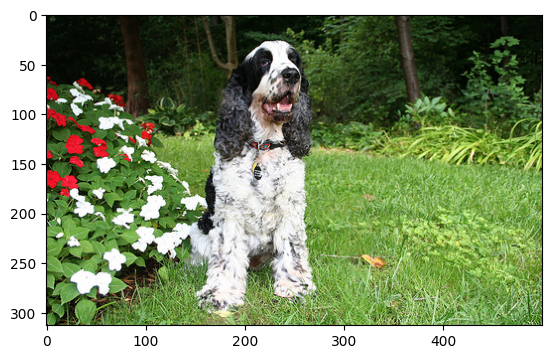

In [6]:
plt.imshow(ski.io.imread(files[0]))

In [7]:
def cat_or_dog(filename):
  if filename[0].isupper():
    return "cat"
  else:
    return "dog"

In [8]:
cat_or_dog("beagle_17.jpg")

'dog'

In [9]:
cat_or_dog("British_Shorthair_174.jpg")

'cat'

In [10]:
dls = ImageDataLoaders.from_name_func(path, files, cat_or_dog, item_tfms=Resize(224))

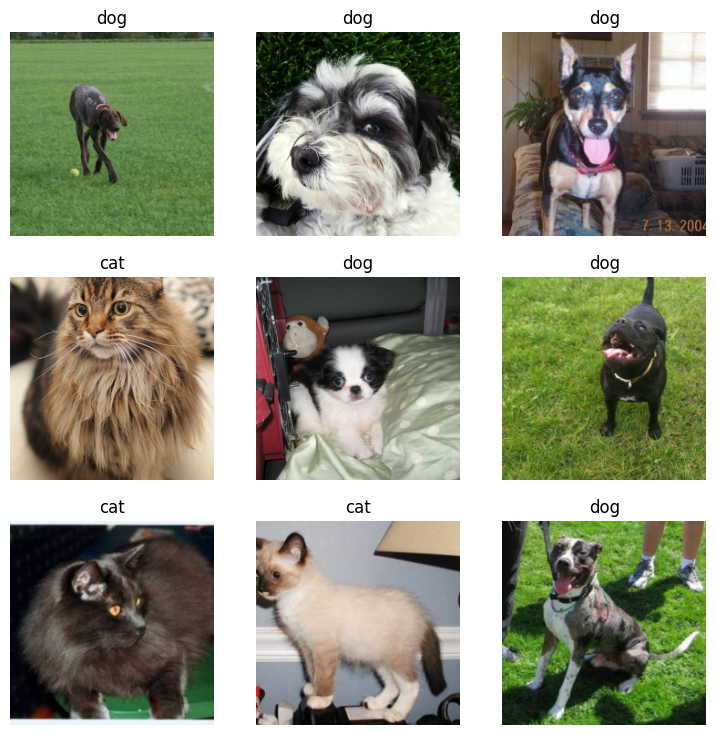

In [11]:
dls.show_batch()

In [12]:
learner = vision_learner(dls, resnet34, metrics=accuracy)

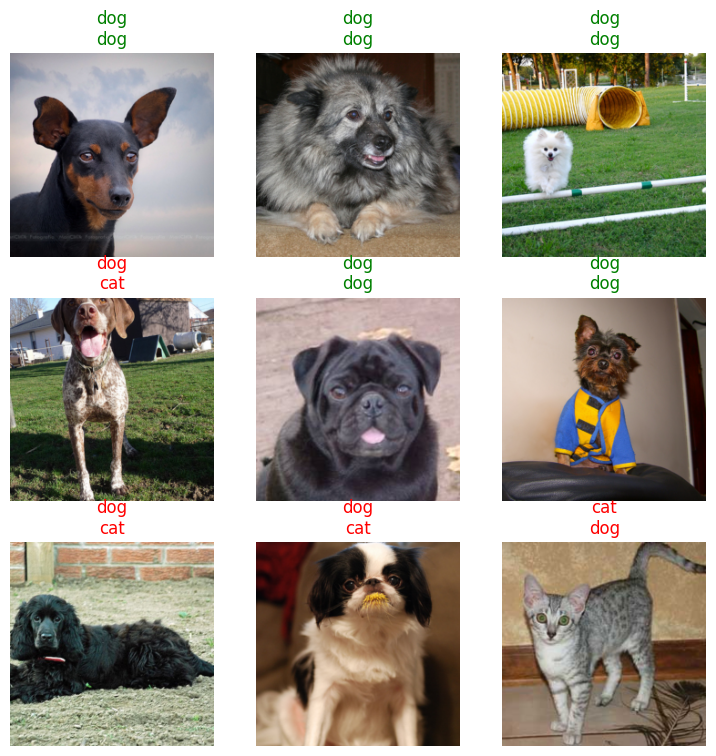

In [14]:
learner.show_results()

In [15]:
learner.validate()

(#2) [1.142382264137268,0.6123139262199402]

In [16]:
learner.fine_tune(1)

epoch,train_loss,valid_loss,accuracy,time
0,0.150175,0.017884,0.996617,11:44


epoch,train_loss,valid_loss,accuracy,time
0,0.048948,0.014803,0.995940,15:58


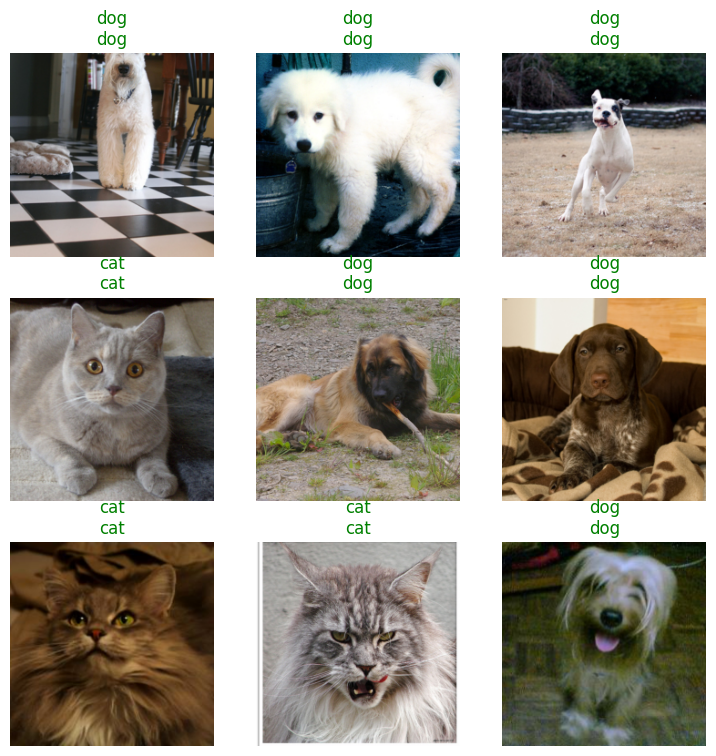

In [17]:
learner.show_results()

In [18]:
import skimage as ski

In [20]:
bernhard = ski.io.imread("https://www.landtiere.de/assets/images/33/856/33856371-eine-frau-haelt-ihren-bernhardiner-welpen-auf-dem-arm-2mMtUE3wONec.jpg")

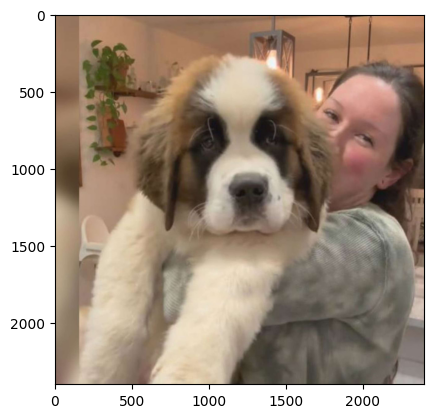

In [21]:
plt.imshow(bernhard)

In [22]:
learner.predict(bernhard)

('dog', tensor(1), tensor([0.0017, 0.9983]))

In [24]:
elefant = ski.io.imread("https://addoelephantpark.de/wp-content/uploads/2025/06/addo-elefant-25-04-19-DSC06221-1.jpg")
learner.predict(elefant)

('dog', tensor(1), tensor([8.3941e-05, 9.9992e-01]))

In [25]:
hachiko = ski.io.imread("https://sumikai.com/wp-content/uploads/2018/01/Hachiko-Statue-in-Shibuya.jpg")
learner.predict(hachiko)

('dog', tensor(1), tensor([0.0046, 0.9954]))

In [ ]:
interpret = ClassificationInterpretation.from_learner(learner)